# Assignment pre-series04 – Python

**IEAP – M1 2SIA – Université de Montpellier**

**Group members:** Valentin BALBINE · Zoé SAUGE · Damien CLANET

| Section | In charge |
|---|---|
| 1. Generate a known signal | Valentin BALBINE |
| 2. Time derivative of the signal | Zoé SAUGE |
| 3. Tangential speed of the signal | Damien CLANET |
| 4. Interactive plot (plotly) + HTML export | whole group |

## 1. Generate a known signal

### 1.a Equation of a sinusoid at 1 Hz, amplitude 1, phase 0

General form: $s(t) = A \sin(2\pi f t + \varphi)$

With $A = 1$, $f = 1\ \text{Hz}$, $\varphi = 0$:

$$s(t) = \sin(2\pi t)$$

### 1.b Time vector

The instructions ask for *1000 samples*, *100 Hz* and *3 s*, which is not consistent (3 s at 100 Hz gives 300 samples), while the expected output shows `t.shape = (100, 1)` over 3 s.
We reproduce the expected output: **100 samples over 3 s** (i.e. an effective sampling frequency of 99/3 = 33 Hz).

`time` is created as a **column vector** (`reshape(-1, 1)`), so that samples are over rows as expected in the assignment.

### 1.c Signal (x, y, z)

Phase shift of $\pi/4$ from x to y and from y to z:

$$x(t) = \sin(2\pi t), \quad y(t) = \sin\!\left(2\pi t + \tfrac{\pi}{4}\right), \quad z(t) = \sin\!\left(2\pi t + \tfrac{\pi}{2}\right)$$

In [7]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt

# --- parameters
duration = 3 # s
n_samples = 100  # number of samples (see note above)
f = 1.0    # Hz
amplitude = 1.0
phase_shift = np.pi / 4   # shift from x to y, and from y to z (try other values!)

# --- time: column vector (n_samples, 1)
time = np.linspace(0, duration, n_samples).reshape(-1, 1)

# --- signal: 2D array (n_samples, 3), columns = x, y, z
phases = np.array([0, 1, 2]) * phase_shift # shape (3,)
signal = amplitude * np.sin(2 * np.pi * f * time + phases)   # broadcasting (n,1) + (3,) -> (n,3)
print(signal.shape)  # (n_samples, 3) 
# (n_samples, 1)

(100, 3)


### 1.d Reproduce the expected output in 2D and in 3D


t.shape = (100, 1)
s.shape = (100, 3)
phase_shift = 0.25 pi


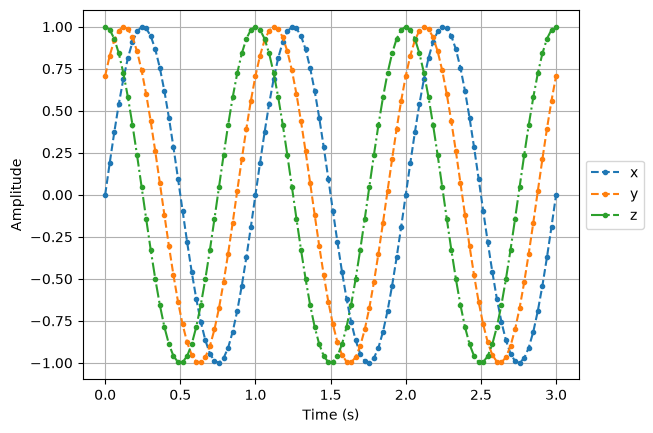

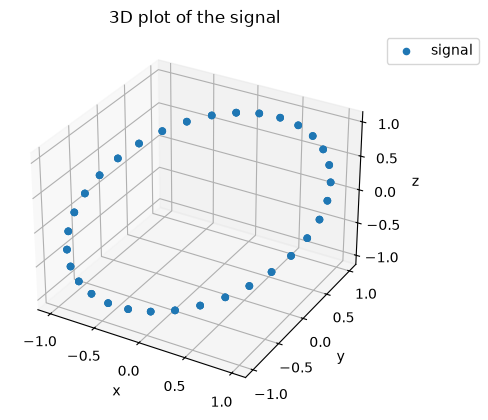

In [8]:
print(f"t.shape = {time.shape}")
print(f"s.shape = {signal.shape}")
print(f"phase_shift = {phase_shift / np.pi:g} pi")

# --- 2D plot
plt.figure()
for i, (label, ls) in enumerate(zip("xyz", ["--", "--", "-."])):
    plt.plot(time, signal[:, i], marker=".", linestyle=ls, label=label)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()  
# --- 3D plot
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(signal[:, 0], signal[:, 1], signal[:, 2], label="signal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D plot of the signal")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()



## 2. Estimate the time derivative of the signal

### 2.a Time derivative of a sine wave

Using the chain rule, with $\omega = 2\pi f$:

$$\frac{d}{dt}\Big[A\sin(\omega t + \varphi)\Big] = A\,\omega\cos(\omega t + \varphi)$$

The derivative is a sine wave of same frequency, amplitude multiplied by $\omega$, and phase advanced by $\pi/2$.


### 2.b Time derivative of `signal` along each axis ($A = 1$, $f = 1$ Hz, $\omega = 2\pi$)

$$\dot{x}(t) = 2\pi\cos(2\pi t)$$

$$\dot{y}(t) = 2\pi\cos\!\left(2\pi t + \tfrac{\pi}{4}\right)$$

$$\dot{z}(t) = 2\pi\cos\!\left(2\pi t + \tfrac{\pi}{2}\right) = -2\pi\sin(2\pi t)$$

The expected amplitude of each derivative is therefore $2\pi \approx 6.28$.

### 2.c Forward difference vs central difference

Both methods approximate the derivative from its definition $\dot{s}(t) = \lim_{h\to 0} \frac{s(t+h)-s(t)}{h}$, with $h$ the sampling interval:

| | Forward difference | Central difference |
|---|---|---|
| Formula | $\dot{s}(t_i) \approx \dfrac{s(t_{i+1}) - s(t_i)}{t_{i+1} - t_i}$ | $\dot{s}(t_i) \approx \dfrac{s(t_{i+1}) - s(t_{i-1})}{t_{i+1} - t_{i-1}}$ |
| Samples used | current and next | previous and next (symmetric around $t_i$) |
| Truncation error | $O(h)$ – first order | $O(h^2)$ – second order, more accurate |
| Time shift | estimates the slope at $t_i + h/2$ but assigns it to $t_i$ → half-sample lag | none (symmetric) |
| Undefined at | last sample | first and last samples |

At the edges, where a method is not defined, we use the one-sided difference (forward at the start, backward at the end), as done by `numpy.gradient`. The output therefore always has the **same shape as the input**.

*References:*
- [Finite difference – Wikipedia](https://en.wikipedia.org/wiki/Finite_difference)
- [numpy.gradient – NumPy documentation](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html)

### 2.d Functions

**Order of the inputs: `(signal, time)`**
- it follows the notation $ds/dt$ (what we differentiate, then with respect to what);
- it is the convention of `numpy.gradient(f, *varargs)`: values first, coordinates second;
- `time` could later become optional (e.g. a default sampling period), and in Python optional arguments must come after the required ones.

**Output shape:** same as `signal`, i.e. `(n_samples, n_dimensions)` → here `(100, 3)`.


In [9]:

# References for the finite differences (see 2.c):
# https://en.wikipedia.org/wiki/Finite_difference
# https://numpy.org/doc/stable/reference/generated/numpy.gradient.html


def _as_columns(signal, time):
    # Format inputs: signal (n_samples, n_dims) and time (n_samples, 1)
    signal = np.asarray(signal, dtype=float)
    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)
    time = np.asarray(time, dtype=float).reshape(-1, 1)
    assert signal.shape[0] == time.shape[0], "signal and time must have the same number of samples"
    assert signal.shape[0] >= 3, "at least 3 samples are needed"
    return signal, time


def derivative_forward(signal, time):
    # Time derivative with the forward difference.
    #   signal: (n_samples, n_dims) array, time: (n_samples, 1) array
    #   returns: (n_samples, n_dims) array
    #   The last sample uses the backward difference.
    signal, time = _as_columns(signal, time)
    deriv = np.empty_like(signal)
    deriv[:-1] = (signal[1:] - signal[:-1]) / (time[1:] - time[:-1])
    deriv[-1] = (signal[-1] - signal[-2]) / (time[-1] - time[-2])
    return deriv


def derivative_central(signal, time):
    # Time derivative with the central difference.
    #   signal: (n_samples, n_dims) array, time: (n_samples, 1) array
    #   returns: (n_samples, n_dims) array
    #   First / last samples use the forward / backward difference.
    signal, time = _as_columns(signal, time)
    deriv = np.empty_like(signal)
    deriv[1:-1] = (signal[2:] - signal[:-2]) / (time[2:] - time[:-2])
    deriv[0] = (signal[1] - signal[0]) / (time[1] - time[0])
    deriv[-1] = (signal[-1] - signal[-2]) / (time[-1] - time[-2])
    return deriv

### 2.e Apply the functions to the signal and plot the result

derivative shape = (100, 3)


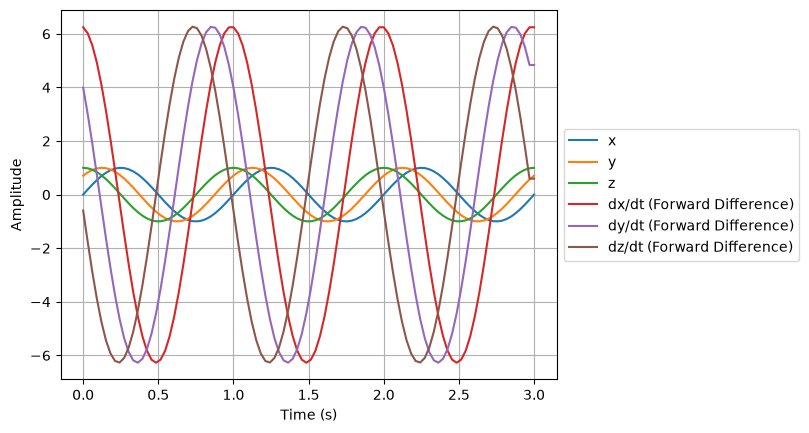

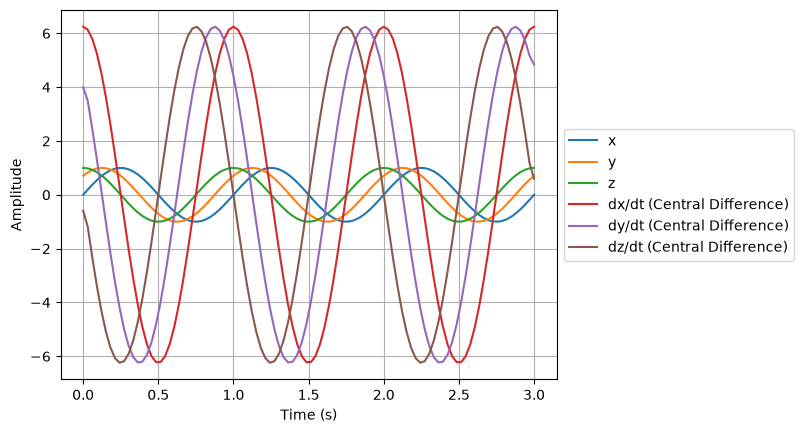

max error, forward difference: 0.597
max error, central difference (interior samples): 0.038


In [10]:
d_forward = derivative_forward(signal, time)
d_central = derivative_central(signal, time)
print(f"derivative shape = {d_central.shape}")

for deriv, method in [(d_forward, "Forward Difference"), (d_central, "Central Difference")]:
    plt.figure()
    plt.plot(time, signal, label=["x", "y", "z"])
    plt.plot(time, deriv, label=[f"dx/dt ({method})", f"dy/dt ({method})", f"dz/dt ({method})"])
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    plt.show()

# Check against the analytical derivative (2.b)
d_true = 2 * np.pi * f * amplitude * np.cos(2 * np.pi * f * time + phases)
print(f"max error, forward difference: {np.max(np.abs(d_forward - d_true)):.3f}")
print(f"max error, central difference (interior samples): {np.max(np.abs(d_central[1:-1] - d_true[1:-1])):.3f}")
# Our central difference gives the same result as numpy.gradient
assert np.allclose(d_central, np.gradient(signal, time.ravel(), axis=0))

## 4. Estimate the tangential speed of the signal

### 4.a Tangential velocity vs tangential speed

- The **tangential velocity** $\vec{v}(t) = \dfrac{d\vec{s}}{dt}$ is a **vector**: it has a magnitude and a direction, and is always tangent to the trajectory.
- The **tangential speed** $v(t) = \|\vec{v}(t)\|$ is a **scalar**: the magnitude of the velocity vector, i.e. how fast the point moves along its path, regardless of the direction.

Example: in uniform circular motion, the speed is constant whereas the velocity changes continuously (its direction rotates).

*References:* [Velocity – Wikipedia](https://en.wikipedia.org/wiki/Velocity) ; [Speed – Wikipedia](https://en.wikipedia.org/wiki/Speed) ; Halliday, Resnick & Walker, *Fundamentals of Physics*, ch. 4 (Motion in two and three dimensions).



4.b Tangential speed of a 3D movement

$$v(t) = \sqrt{\dot{x}(t)^2 + \dot{y}(t)^2 + \dot{z}(t)^2}$$

### 4.c Tangential speed of an nD movement

With $\vec{s}(t) = \big(s_1(t), \dots, s_n(t)\big)^T$, the speed is the Euclidean norm of the velocity vector:

$$v(t) = \left\| \dot{\vec{s}}(t) \right\|_2 = \sqrt{\dot{\vec{s}}(t)^T\,\dot{\vec{s}}(t)} = \sqrt{\sum_{i=1}^{n} \dot{s}_i(t)^2}$$

In matrix form, with $\dot{S}$ the $(N \times n)$ matrix of velocities (samples over rows), $v$ is the square root of the row-wise sum of squares of $\dot{S}$.

*Reference:* [Norm (mathematics) – Euclidean norm, Wikipedia](https://en.wikipedia.org/wiki/Norm_(mathematics)#Euclidean_norm)

### 4.d Function

**Order of inputs:** `(signal, time)`, for the same reasons as in 3.d, and to stay consistent with the derivative functions it calls.

**Output shape:** `(n_samples, 1)` – one scalar per sample, as a column vector like `time`. The number of columns no longer depends on the number of dimensions of the movement.

We use the central difference (more accurate, see 3.c).